# Бассейны Ньютона

Для каждой начальной точки комплексной плоскости повторим итерацию

$$z_{n+1}=G(z_n)=z_n-\frac{f(z_n)}{f'(z_n)}.$$

Бассейн притяжения корня — множество начальных точек, из которых итерации сходятся к этому корню. Раскрасим исходные точки по результату итераций.

Сохраним основной полином исходного скрипта: $f(z)=z^3-2z+2$. У его отображения Ньютона есть не только три корня, но и притягивающий цикл $0\leftrightarrow1$. Покажем этот цикл отдельным цветом.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# Коэффициенты от старшей степени к младшей.
Coefficients = np.array([1.0, 0.0, -2.0, 2.0])
DerivativeCoefficients = np.polyder(Coefficients)


def F(z):
    return np.polyval(Coefficients, z)


def dF(z):
    return np.polyval(DerivativeCoefficients, z)


def G(z):
    return z - F(z)/dF(z)


X_min, X_max = -2.0, 2.0
Y_min, Y_max = -2.0, 2.0
X_Counts, Y_Counts = 500, 500
Steps = 100
Tol = 1e-8

XSpace_0 = np.linspace(X_min, X_max, X_Counts).reshape(1, -1)
YSpace_0 = np.linspace(Y_min, Y_max, Y_Counts).reshape(-1, 1)
ZSpace_0 = XSpace_0 + 1j*YSpace_0
Extent = [X_min, X_max, Y_min, Y_max]

## Определение результата итераций

В отличие от окраски только по аргументу $z_n$, итоговая карта явно различает результаты:

- корень: точка близка к одному из вычисленных корней и имеет малую невязку;
- известный цикл $0\leftrightarrow1$: два соседних приближения близки к разным точкам цикла;
- численный сбой: производная слишком мала или вычисления дали неконечные значения;
- исход не определён за заданное число шагов.

Последняя категория не означает доказанной расходимости. Карта является численной классификацией с заданными допусками и разрешением.

Храним текущее и предыдущее состояния, метки исходов и номера итераций. Распознанные точки больше не обновляем. Корни для классификации находим через `np.roots`; сами итерации по сетке выполняем явно.

In [10]:
def newton_basins(coefficients, initial, max_iter=Steps, tol=Tol, cycle=None):
    """Классифицирует начальные точки; cycle — известная пара точек периода 2."""
    roots = np.roots(coefficients)
    roots = roots[np.lexsort((roots.imag, roots.real))]
    derivative_coefficients = np.polyder(coefficients)
    shape = np.shape(initial)
    Z = np.asarray(initial, dtype=complex).ravel().copy()
    previous = Z.copy()
    labels = np.full(Z.size, -1, dtype=int)  # -1: исход ещё не определён
    counts = np.full(Z.size, max_iter, dtype=int)
    cycle_label, failure_label = len(roots), len(roots) + 1

    for iteration in range(max_iter + 1):
        indices = np.flatnonzero(labels == -1)
        if indices.size == 0:
            break
        values = Z[indices]
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            residuals = np.polyval(coefficients, values)
        finite = np.isfinite(values) & np.isfinite(residuals)
        failed = indices[~finite]
        labels[failed], counts[failed] = failure_label, iteration
        indices, values, residuals = indices[finite], values[finite], residuals[finite]
        if indices.size == 0:
            continue

        distances = np.abs(values[:, None] - roots[None, :])
        nearest = np.argmin(distances, axis=1)
        at_root = (np.min(distances, axis=1) <= tol) & (np.abs(residuals) <= tol)
        labels[indices[at_root]] = nearest[at_root]
        counts[indices[at_root]] = iteration

        if cycle is not None and iteration > 0:
            a, b = cycle
            old = previous[indices]
            at_cycle = (((np.abs(values-a) <= tol) & (np.abs(old-b) <= tol))
                        | ((np.abs(values-b) <= tol) & (np.abs(old-a) <= tol)))
            at_cycle &= ~at_root
            labels[indices[at_cycle]], counts[indices[at_cycle]] = cycle_label, iteration

        if iteration == max_iter:
            break
        indices = np.flatnonzero(labels == -1)
        values = Z[indices]
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            derivatives = np.polyval(derivative_coefficients, values)
            valid = np.isfinite(derivatives) & (np.abs(derivatives) >= 1e-14)
            failed = indices[~valid]
            labels[failed], counts[failed] = failure_label, iteration
            indices, values, derivatives = indices[valid], values[valid], derivatives[valid]
            previous[indices] = values
            Z[indices] = values - np.polyval(coefficients, values)/derivatives

    return {"labels": labels.reshape(shape), "counts": counts.reshape(shape),
            "roots": roots, "last": Z.reshape(shape), "max_iter": max_iter,
            "cycle": cycle}

In [11]:
def show_basins(result, extent, title):
    roots, cycle = result["roots"], result["cycle"]
    # Номера категорий: корни, цикл, сбой, неопределённый исход.
    colors = list(plt.cm.tab10.colors[:len(roots)]) + (["gold"] if cycle is not None else []) + ["black", "lightgray"]
    names = ([f"Корень {i+1}" for i in range(len(roots))]
             + (["Цикл 0 ↔ 1"] if cycle is not None else [])
             + ["Численный сбой", "Не определено"])
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(len(colors)+1)-0.5, len(colors))
    labels = result["labels"]
    image_labels = labels.copy()
    image_labels[labels == len(roots)+1] = len(colors)-2
    image_labels[labels < 0] = len(colors)-1

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    im = axes[0].imshow(image_labels, origin="lower", extent=extent,
                        cmap=cmap, norm=norm, interpolation="nearest")
    ticks = list(range(len(colors)))
    colorbar = fig.colorbar(im, ax=axes[0], ticks=ticks, fraction=0.045, pad=0.04)
    colorbar.ax.set_yticklabels([names[i] for i in ticks])
    axes[0].scatter(roots.real, roots.imag, marker="o", s=35,
                    facecolors="white", edgecolors="black")
    if cycle is not None:
        axes[0].scatter(np.real(cycle), np.imag(cycle), marker="s", s=25,
                        facecolors="white", edgecolors="black")
    recognized = (labels >= 0) & (labels <= len(roots))
    im_steps = axes[1].imshow(np.ma.masked_where(~recognized, result["counts"]),
                              origin="lower", extent=extent, cmap="viridis",
                              vmin=0, vmax=result["max_iter"], interpolation="nearest")
    fig.colorbar(im_steps, ax=axes[1], label="Число итераций", fraction=0.045, pad=0.04)
    axes[0].set_title("Бассейны корней и известного цикла" if cycle is not None else "Бассейны корней")
    axes[1].set_title("Итерации до распознавания корня или цикла" if cycle is not None else "Итерации до распознавания корня")
    for ax in axes:
        ax.set(xlabel="Re(z₀)", ylabel="Im(z₀)", aspect="equal")
    fig.suptitle(f"{title}; сетка {labels.shape[1]} × {labels.shape[0]}, лимит {result['max_iter']} шагов")
    fig.tight_layout()
    plt.show()

    for i, root in enumerate(roots):
        print(f"Корень {i+1}: {root:.6f}; точек сетки: {np.count_nonzero(labels == i)}")
    if cycle is not None:
        print("Цикл 0 ↔ 1:", np.count_nonzero(labels == len(roots)))
    print("Численный сбой:", np.count_nonzero(labels == len(roots)+1))
    print("Не определено за лимит:", np.count_nonzero(labels == -1))

## Основной пример: $z^3-2z+2$

Точки цикла не являются корнями: $f(0)=2$, $f(1)=1$, но $G(0)=1$ и $G(1)=0$.

Для $G(z)=z-f(z)/f'(z)$ имеем $G'(z)=f(z)f''(z)/(f'(z))^2$. Поэтому $G'(0)=0$ и мультипликатор цикла $G'(0)G'(1)=0$: цикл притягивающий. На карте у него есть собственный бассейн.

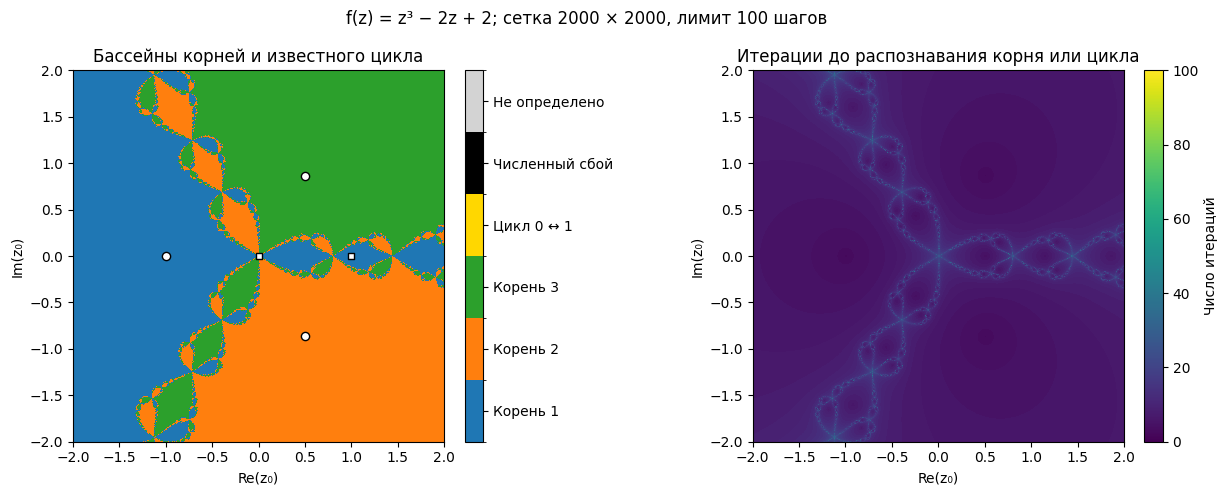

Корень 1: -1.000000+0.000000j; точек сетки: 1411254
Корень 2: 0.500000-0.866025j; точек сетки: 1294373
Корень 3: 0.500000+0.866025j; точек сетки: 1294373
Цикл 0 ↔ 1: 0
Численный сбой: 0
Не определено за лимит: 0


In [12]:
CycleResult = newton_basins(Coefficients, ZSpace_0, cycle=(0j, 1+0j))
show_basins(CycleResult, Extent, "f(z) = z³ − 2z + 2")

## Для сравнения: $z^3-1$

Второй короткий запуск показывает классическую картину трёх бассейнов. Точки, оставшиеся неопределёнными, можно исследовать, увеличив лимит итераций или пересчитав выбранный участок на более мелкой сетке. Увеличение готовой картинки не заменяет пересчёт.

In [ ]:
CubicResult = newton_basins([1.0, 0.0, 0.0, -1.0], ZSpace_0)
show_basins(CubicResult, Extent, "f(z) = z³ − 1")

## Анимация исходного примера

Сохраним идею исходного скрипта: цвет показывает $\arg z_n$ по мере итераций для $f(z)=z^3-2z+2$. Это визуализация текущих значений, а не классификация бассейнов. Для классификации служат карты выше.

Для небольшой анимации используем сетку $160\times160$ и 24 кадра. Полную историю комплексных массивов не храним; Matplotlib сохраняет только кадры для воспроизведения в ноутбуке.

In [ ]:
animation_axis = np.linspace(-2, 2, 160)
animation_initial = animation_axis[None, :] + 1j*animation_axis[:, None]
animation_state = animation_initial.copy()

fig, ax = plt.subplots(figsize=(5, 4))
phase_image = ax.imshow(np.angle(animation_state), cmap="hsv", vmin=-np.pi, vmax=np.pi,
                        extent=Extent, origin="lower", interpolation="nearest")
fig.colorbar(phase_image, ax=ax, label="arg(zₙ), рад")
ax.set(xlabel="Re(z₀)", ylabel="Im(z₀)")
title = ax.set_title("f(z) = z³ − 2z + 2; n = 0")
fig.tight_layout()


def init_animation():
    animation_state[:] = animation_initial
    phase_image.set_data(np.angle(animation_state))
    title.set_text("f(z) = z³ − 2z + 2; n = 0")
    return phase_image, title


def update_animation(frame):
    if frame > 0:
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            animation_state[:] = G(animation_state)
    phase_image.set_data(np.angle(animation_state))
    title.set_text(f"f(z) = z³ − 2z + 2; n = {frame}")
    return phase_image, title


ani = FuncAnimation(fig, update_animation, init_func=init_animation,
                    frames=24, interval=250, repeat=False)
animation_html = ani.to_jshtml()
plt.close(fig)
display(HTML(animation_html))

**Попробуйте:**

- Сравнить карты при 30 и 100 итерациях. Где меняется категория «не определено»?
- Пересчитать небольшой участок границы на новой сетке.
- Вызвать `newton_basins` для коэффициентов `[1, -6, 11, -6]`, то есть $(z-1)(z-2)(z-3)$, или для $z^7-1$. Параметр `cycle` для них не задавать: в коде проверяется именно известный цикл, а не произвольные периодические орбиты.

В последнем случае область изображения нужно выбирать так, чтобы нужные корни попадали в кадр. Для $(z-1)(z-2)(z-3)$ удобно взять $\operatorname{Re}z\in[0,4]$ и $\operatorname{Im}z\in[-2,2]$.